In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df_perturb = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/perturb_2_decisionTree copy.csv")

In [4]:
top_20 = df_perturb.nlargest(10, "scores")

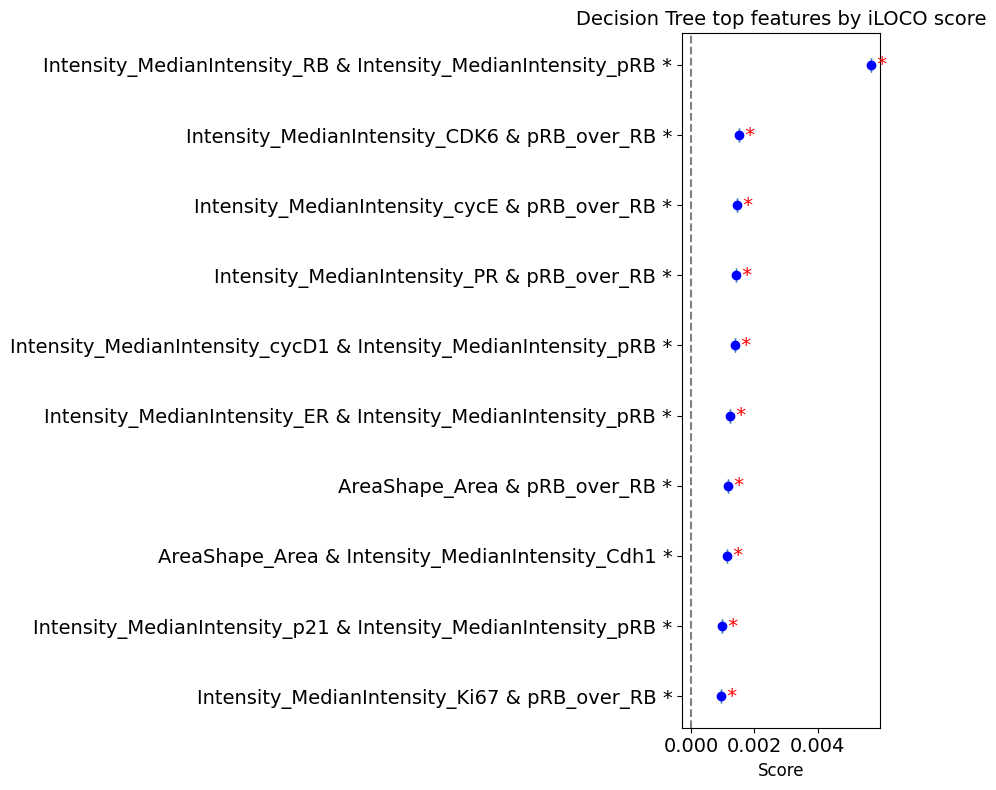

In [5]:
# Plot
# Copy feature names so we can modify them without affecting the original DataFrame
ytick_labels = top_20["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20["scores"], top_20["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["scores"],
    top_20["feature"],
    xerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)  # Rotate x-axis labels vertically
plt.xlabel("Score", fontsize=12)
plt.title("Decision Tree top features by iLOCO score", fontsize=14)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20["scores"], top_20["ci"], top_20["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.yticks(ticks=top_20["feature"], labels=ytick_labels, fontsize=14)

plt.gca().invert_yaxis()  # Reverse y-axis

plt.tight_layout()
plt.show()

In [6]:
top_20

,feature,scores,ci
171,Intensity_MedianIntensity_RB & Intensity_Media...,0.005683,0.0
88,Intensity_MedianIntensity_CDK6 & pRB_over_RB,0.001501,0.0
202,Intensity_MedianIntensity_cycE & pRB_over_RB,0.001451,0.0
163,Intensity_MedianIntensity_PR & pRB_over_RB,0.001425,0.0
197,Intensity_MedianIntensity_cycD1 & Intensity_Me...,0.001381,0.0
141,Intensity_MedianIntensity_ER & Intensity_Media...,0.001244,0.0
18,AreaShape_Area & pRB_over_RB,0.001154,0.0
4,AreaShape_Area & Intensity_MedianIntensity_Cdh1,0.001122,0.0
204,Intensity_MedianIntensity_p21 & Intensity_Medi...,0.000985,0.0
153,Intensity_MedianIntensity_Ki67 & pRB_over_RB,0.000950,0.0


In [8]:
df_no_perturb = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/no_perturb_2_decisionTree.csv")

In [9]:
top_20 = df_no_perturb.nlargest(10, "scores")

In [10]:
top_20

,feature,scores,ci
171,Intensity_MedianIntensity_RB & Intensity_Media...,0.006196,0.0
37,Intensity_IntegratedIntensity_DNA & pRB_over_RB,0.002945,0.0
88,Intensity_MedianIntensity_CDK6 & pRB_over_RB,0.001390,0.0
197,Intensity_MedianIntensity_cycD1 & Intensity_Me...,0.001364,0.0
62,Intensity_MedianIntensity_CDK4 & Intensity_Med...,0.001240,0.0
18,AreaShape_Area & pRB_over_RB,0.001165,0.0
202,Intensity_MedianIntensity_cycE & pRB_over_RB,0.001165,0.0
187,Intensity_MedianIntensity_cycA & pRB_over_RB,0.001067,0.0
75,Intensity_MedianIntensity_CDK6 & Intensity_Med...,0.001060,0.0
151,Intensity_MedianIntensity_Ki67 & Intensity_Med...,0.001046,0.0
